<a href="https://colab.research.google.com/github/pankhudi-priyal/ai-vs-human-text-detection/blob/main/3_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/AI_Human.csv')
print("Dataset loaded! Shape:", df.shape)

Mounted at /content/drive
Dataset loaded! Shape: (487235, 2)


Training samples: 8000
Testing samples:  2000

Loading BERT tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training BERT (this will take 15-30 mins)...
  Epoch 1 | Step 50/500 | Loss: 0.4399 | Acc: 0.7975
  Epoch 1 | Step 100/500 | Loss: 0.3053 | Acc: 0.8694
  Epoch 1 | Step 150/500 | Loss: 0.2484 | Acc: 0.8962
  Epoch 1 | Step 200/500 | Loss: 0.2248 | Acc: 0.9087
  Epoch 1 | Step 250/500 | Loss: 0.2084 | Acc: 0.9177
  Epoch 1 | Step 300/500 | Loss: 0.1875 | Acc: 0.9275
  Epoch 1 | Step 350/500 | Loss: 0.1752 | Acc: 0.9330
  Epoch 1 | Step 400/500 | Loss: 0.1642 | Acc: 0.9383
  Epoch 1 | Step 450/500 | Loss: 0.1540 | Acc: 0.9421
  Epoch 1 | Step 500/500 | Loss: 0.1459 | Acc: 0.9453
Epoch 1 complete — Avg Loss: 0.1459 | Acc: 0.9453
  Epoch 2 | Step 50/500 | Loss: 0.0394 | Acc: 0.9912
  Epoch 2 | Step 100/500 | Loss: 0.0441 | Acc: 0.9862
  Epoch 2 | Step 150/500 | Loss: 0.0400 | Acc: 0.9875
  Epoch 2 | Step 200/500 | Loss: 0.0393 | Acc: 0.9869
  Epoch 2 | Step 250/500 | Loss: 0.0427 | Acc: 0.9860
  Epoch 2 | Step 300/500 | Loss: 0.0402 | Acc: 0.9867
  Epoch 2 | Step 350/500 | Loss: 0.0386 | 

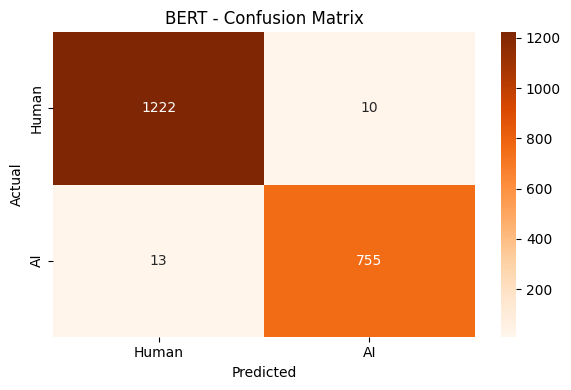

Done!


In [3]:
# ============================================
# BERT MODEL
# ============================================

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW

# Prepare Data
df_sample = df.sample(n=10000, random_state=42)

X = df_sample['text'].astype(str).values
y = df_sample['generated'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Load BERT Tokenizer
print("\nLoading BERT tokenizer...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize Text
def tokenize(texts, max_len=128):
    return tokenizer(
        list(texts),
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

print("Tokenizing training data...")
train_encodings = tokenize(X_train)
print("Tokenizing test data...")
test_encodings  = tokenize(X_test)

# Create Dataset Class
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = TextDataset(train_encodings, y_train)
test_dataset  = TextDataset(test_encodings,  y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16)

# Load BERT Model
print("\nLoading BERT model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2
)
model.to(device)

# Train
optimizer = AdamW(model.parameters(), lr=2e-5)

print("\nTraining BERT (this will take 15-30 mins)...")
EPOCHS = 3
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0

    for i, batch in enumerate(train_loader):
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids,
                       attention_mask=attention_mask,
                       labels=labels)

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if (i+1) % 50 == 0:
            print(f"  Epoch {epoch+1} | Step {i+1}/{len(train_loader)} | "
                  f"Loss: {total_loss/(i+1):.4f} | "
                  f"Acc: {correct/total:.4f}")

    print(f"Epoch {epoch+1} complete — "
          f"Avg Loss: {total_loss/len(train_loader):.4f} | "
          f"Acc: {correct/total:.4f}")

# Evaluate
print("\nEvaluating...")
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids,
                       attention_mask=attention_mask)
        preds   = outputs.logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=['Human', 'AI']))

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Human', 'AI'],
            yticklabels=['Human', 'AI'])
plt.title('BERT - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('bert_confusion_matrix.png')
plt.show()
print("Done!")

In [11]:
import nbformat

with open('/content/drive/MyDrive/Colab Notebooks/avh-BERT.ipynb', 'r') as f:
    nb = nbformat.read(f, as_version=4)
if 'widgets' in nb.metadata:
    del nb.metadata['widgets']
with open('/content/drive/MyDrive/Colab Notebooks/avh-BERT.ipynb', 'w') as f:
    nbformat.write(nb, f)

print("Fixed! ✅")

Fixed! ✅
